# Social Survey 2024 - Data Cleaning and General Statistics

**Project context:** Financial vulnerability risk scoring based on the Israeli Social Survey financial module.

**Notebook owner:** Data ingestion, data cleaning, missing-value audit, initial feature organization, and descriptive statistics.

This notebook intentionally **does not perform scaling** and **does not fit any imputation/scaling object before the train/test split**. The goal is to prepare a clean, transparent analysis table for the modeling team while avoiding data leakage.


## 0. Working principles

1. Keep the raw file unchanged.
2. Convert survey-specific non-response codes such as `888888` and `999999` into real missing values (`NaN`).
3. Document missingness instead of silently deleting many rows.
4. Do not scale here. Scaling belongs inside the modeling pipeline after the train/test split.
5. Any imputation used for modeling should be fitted on the training set only. In this notebook we mainly audit missing values and create clear feature groups.


In [1]:
# Core imports
from pathlib import Path
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

print("import successful!")

import successful!


## 1. Load data

For Git-based work, keep the data path relative to the repository. A common structure is:

```text
project_root/
├── data/
│   ├── raw/
│   │   └── data_24.xlsx
│   └── processed/
├── notebooks/
└── src/
```

Update `DATA_PATH` if your repository uses a different folder structure.


In [2]:
# Load the Social Survey dataset
raw = pd.read_excel("data_24.xlsx", sheet_name="data_24")

print(f"Rows: {raw.shape[0]:,}")
print(f"Columns: {raw.shape[1]:,}")

raw.head()


Rows: 6,907
Columns: 324


,SerialNumber,Shana,SemelEretz,SemelEretzAv_C,SemelEretzEm_C,ShnatAliya,MatzavMishp,VetekMatzavMishpN,VetekMatzavMishpG,VetekMatzavMishpA,All_School,High_School,Matriculation_Certificate,Post_Secondary,Ba,Ma,Phd,Kids_0_5,Kids_6_17,over_18,Bnei20plus,Kids_0_17,BenZug,SugMeshekBait_C,BenZugOved,Minn,Gil,PeamimNasuy,ms_nefashot,HesderDiyur,GoremMaskirDira,MispChadarim,DiraNosefetBaalut,DiraBaalut,Mechonit,MechonitBashana,Ozeret,OzeretShaot,OzeretTaasuka,OzeretTashlumAtem,OzeretTashlumMosad,OzeretTashlumAcher,VetekYishuv,MerutzeEzor,MerutzeTachbura,MerutzeEzorParkim,MerutzeEzorNikayon,MerutzeEzorAshpa,MafriaZihum,MargishBatuach,HanayaMaspik,MerutzeKvishim,VetekDira,MerutzeDira,MafriaRaash,MerutzeSchenim,SchenimMeshaper,EzorEmunArnak,MatzavBriut,BeayaBriut,...,HashpaaYoetz,HashpaaHamlatza,HashpaaHamlatzaZar,HashpaaPirsum,HashpaaTikshoret,HashpaaAcher,InternetHalvaa,InternetMeida,InternetDohAshrai,InternetShilemMatbeaDig,InternetDohPensia,MerutzeKalkali1_5,KisuyHotzaot1_5,YedaHashkaa,SikunHashkaot,LoHosech,HeshbonotBazman,MatzavMagbil,MatarotKaspiot,ShokelKniot,NisharKesef,HishuvInflation,HishuvRibit100_C,HishuvRibitShana_C,HishuvRibit5Shanim,BituyTsua,BituyInflation,BituyShukHahon,zurat_yishuv,machoz,nafa,pop_group,MechonitReshut_C,Mechonitbaalut_C,MatzavTaasukaM_C,Zurat_YishuvAvoda_C_wp,MispMekomot_C,HekefMisra_C_wp,DiraBaalut_C,Earners,YelidBrham,TzfifutDiyurM,hachnasa_lenefesh,PaamAchronachashavani_C,Mugbalim,AflayaM,MichyaPensyaAtid,MichyaGemelAtid,MichyaKitzbaAtid,MichyaMechiratNechesAtid,MichyaMechiratFinanceAtid,MichyaHachnasaMinechesAtid,MichyaMishpachaAtid,MichyaYerushaAtid,MichyaAvodaAtid,MichyaAcherAtid,nn,age_r,DatiutLoYehudi_r,haredi
0,1,24,1,4,2,999999,4,999999,999999,2,0,0,2,0,0,1,0,2,1,1,2,1,2,3,999999,1,7,1,4,1,999999,5,2,999999,1,999999,2,999999,999999,999999,999999,999999,5,1,4,2,4,4,3,1,1,1,4,1,4,1,2,1,1,2,...,1,2,2,2,1,2,2,1,2,2,1,1,5,1,1,5,5,1,3,3,1,3,0,2,1,1,1,1,14,4,44,1,2,2,1,999999,1,2,1,2,2,1,888888,4,2,2,1,2,1,2,2,2,2,1,1,2,1175.182179,4,NaN,0.0
1,2,24,1,2,2,999999,1,3,999999,999999,0,1,1,0,0,0,0,1,1,2,2,1,1,3,1,1,3,1,6,2,1,3,999999,1,2,2,2,999999,999999,999999,999999,999999,2,1,2,2,2,1,4,1,1,2,2,1,4,1,1,1,1,2,...,2,1,2,2,1,2,2,1,1,2,1,1,5,5,4,5,1,4,1,1,4,3,0,888888,888888,2,1,888888,1,1,11,1,0,0,3,999999,999999,999999,1,1,2,3,1,4,2,1,2,2,2,2,2,2,1,2,999999,2,2878.604304,2,NaN,1.0
2,3,24,1,3,3,999999,1,4,999999,999999,0,0,2,0,0,0,0,2,2,2,2,2,1,3,2,2,10,1,2,1,999999,5,2,999999,1,999999,1,1,1,1,2,2,5,1,5,1,1,1,3,2,3,1,5,1,2,2,888888,1,2,1,...,2,2,2,2,2,2,2,1,2,2,2,1,5,1,3,3,1,5,5,1,1,888888,0,3,1,1,1,1,16,3,31,1,2,2,3,999999,999999,999999,1,0,2,1,3,4,2,2,999999,999999,999999,999999,999999,999999,999999,999999,999999,999999,854.245090,6,NaN,0.0
3,4,24,3,999999,999999,7,1,4,999999,999999,0,0,0,0,1,1,0,2,2,2,2,2,1,3,1,1,8,1,2,2,1,3,999999,1,1,999999,2,999999,999999,999999,999999,999999,5,1,1,1,1,1,4,2,1,2,3,2,4,2,4,2,2,2,...,1,2,2,2,1,2,2,2,1,2,1,2,5,3,5,5,1,1,2,1,1,3,0,2,1,1,1,888888,15,5,51,1,1,0,1,888888,1,2,1,2,1,1,3,4,2,2,1,1,1,2,2,2,1,2,1,2,1000.984314,5,NaN,0.0
4,5,24,1,1,1,999999,5,999999,999999,999999,0,1,0,0,0,0,0,2,2,2,1,2,2,1,999999,1,2,999999,1,2,3,2,999999,2,2,2,2,999999,999999,999999,999999,999999,1,2,2,2,2,2,4,2,1,2,1,2,4,888888,888888,888888,1,2,...,2,2,2,2,2,2,2,2,2,2,2,5,1,5,5,5,2,2,3,1,4,3,0,888888,888888,888888,888888,888888,15,6,62,2,0,0,1,15,1,2,2,1,2,1,3,1,2,1,2,2,1,888888,2,888888,888888,888888,888888,2,911.110576,2,0.0,NaN


## 2. Initial structure checks

These checks help us understand the dataset before changing anything.


In [3]:
structure_summary = pd.DataFrame({
    "column": raw.columns,
    "dtype": raw.dtypes.astype(str).values,
    "n_unique": raw.nunique(dropna=False).values,
    "missing_before_cleaning": raw.isna().sum().values,
    "missing_before_cleaning_pct": raw.isna().mean().round(4).values
})

structure_summary.head(20)


,column,dtype,n_unique,missing_before_cleaning,missing_before_cleaning_pct
0,SerialNumber,int64,6907,0,0.0
1,Shana,int64,1,0,0.0
2,SemelEretz,int64,4,0,0.0
3,SemelEretzAv_C,int64,6,0,0.0
4,SemelEretzEm_C,int64,6,0,0.0
5,ShnatAliya,int64,9,0,0.0
6,MatzavMishp,int64,5,0,0.0
7,VetekMatzavMishpN,int64,6,0,0.0
8,VetekMatzavMishpG,int64,6,0,0.0
9,VetekMatzavMishpA,int64,6,0,0.0


In [4]:
print("Duplicate SerialNumber rows:", raw["SerialNumber"].duplicated().sum() if "SerialNumber" in raw.columns else "SerialNumber column not found")
print("Fully duplicated rows:", raw.duplicated().sum())


Duplicate SerialNumber rows: 0
Fully duplicated rows: 0


## 3. Convert survey non-response codes to `NaN`

The dataset uses special numeric codes for missing/non-response categories. In this file, the main codes are:

- `888888` — usually non-response / unknown / refused, depending on the survey codebook.
- `999999` — usually not applicable / skipped, depending on the survey codebook.

Because we do not have the full codebook inside this notebook, we keep a conservative approach: we convert these technical codes to `NaN`, and we preserve a missingness report for transparency.


In [5]:
SPECIAL_MISSING_CODES = [888888, 999999]

df = raw.copy(deep=True)

for code in SPECIAL_MISSING_CODES:
    df = df.mask(df == code, np.nan)
    
missing_after = (
    pd.DataFrame({
        "column": df.columns,
        "dtype_after_cleaning": df.dtypes.astype(str).values,
        "missing_n": df.isna().sum().values,
        "missing_pct": df.isna().mean().round(4).values,
        "n_unique_after_cleaning": df.nunique(dropna=False).values
    })
    .sort_values("missing_pct", ascending=False)
    .reset_index(drop=True)
)

missing_after.head(15)


,column,dtype_after_cleaning,missing_n,missing_pct,n_unique_after_cleaning
0,MichyaAvoda,float64,6907,1.0000,1
1,SibaLoZamin,float64,6880,0.9961,6
2,Zminut,float64,6651,0.9629,3
3,Oved35_wp,float64,6599,0.9554,3
4,VetekMatzavMishpA,float64,6592,0.9544,5
5,VetekMatzavMishpG,float64,6336,0.9173,5
6,MeunyanYoterM35,float64,6239,0.9033,3
7,OzeretShaot,float64,6085,0.8810,5
8,OzeretTashlumAcher,float64,6050,0.8759,3
9,OzeretTashlumMosad,float64,6049,0.8758,3


High missing-value percentages were expected for many variables because the Social Survey uses conditional (skip-pattern) questions.

Examples include:
- Year of immigration (asked only to immigrants)
- Landlord information (asked only to renters)
- Employment-related questions (asked only to employed or unemployed respondents)

Therefore, variables were **not removed solely based on their missing-value percentage**. Each variable was evaluated using the official survey codebook.


In [51]:
missing_pct = df.isna().mean()

missing_groups = pd.cut(
    missing_pct,
    bins=[-0.01, 0.05, 0.30, 0.70, 0.99, 1.00],
    labels=[
        "Low missing (0–5%)",
        "Moderate missing (5–30%)",
        "High missing (30–70%)",
        "Very high missing (70–99%)",
        "Fully missing (100%)"
    ],
    include_lowest=True
)

print(missing_groups.value_counts().sort_index())

Low missing (0–5%)            174
Moderate missing (5–30%)       52
High missing (30–70%)          70
Very high missing (70–99%)     28
Fully missing (100%)            1
Name: count, dtype: int64


### Load the Survey Codebook

The survey codebook was loaded to provide metadata for each questionnaire variable, including variable names, question numbers, response categories, and survey-specific notes. This information is used throughout the notebook to identify valid response codes, distinguish structural missing values from true missing data, and guide the construction of derived variables.

In [57]:
codebook_path = "H20241501codebook.xlsx"

xl = pd.ExcelFile(codebook_path)

codebook = pd.read_excel(codebook_path, sheet_name=xl.sheet_names[0])

codebook["field_name"] = codebook["field_name"].ffill()
codebook["variavle_name"] = codebook["variavle_name"].ffill()
codebook["מס' השאלה"] = codebook["מס' השאלה"].ffill()
codebook["הערה"] = codebook["הערה"].ffill()

codebook.head(20)


,מס' השאלה,field_name,variavle_name,code,code_title,הערה
0,NaN,מספר סידורי,SerialNumber,מספר רציף,NaN,NaN
1,NaN,שנת סקר,Shana,24,2024,NaN
2,NaN,מחוז,Machoz,1,ירושלים,מנהלי
3,NaN,מחוז,Machoz,2,הצפון,מנהלי
4,NaN,מחוז,Machoz,3,חיפה,מנהלי
5,NaN,מחוז,Machoz,4,המרכז,מנהלי
6,NaN,מחוז,Machoz,5,תל אביב,מנהלי
7,NaN,מחוז,Machoz,6,הדרום,מנהלי
8,NaN,מחוז,Machoz,7,יהודה ושומרון,מנהלי
9,NaN,נפה,Nafa,11,ירושלים,מנהלי


In [8]:
metadata = (
    codebook[
        ["variavle_name", "field_name", "מס' השאלה", "הערה"]
    ]
    .drop_duplicates(subset="variavle_name")
    .rename(columns={
        "variavle_name": "variable",
        "field_name": "description",
        "מס' השאלה": "question_number",
        "הערה": "note"
    })
)

metadata.head(10)


,variable,description,question_number,note
0,SerialNumber,מספר סידורי,NaN,NaN
1,Shana,שנת סקר,NaN,NaN
2,Machoz,מחוז,NaN,מנהלי
9,Nafa,נפה,NaN,מנהלי
25,Zurat_Yishuv,צורת יישוב,מחושב,ב-2021 חדרה והרצליה וב-2022 כפר סבא ומודיעין ...
39,SugMeshekBait_C,מבנה משק הבית,מחושב,מחושב
43,ms_Nefashot,מספר נפשות במשק הבית,מחושב,מחושב
50,Earners,מספר מפרנסים במשק הבית,מחושב,מחושב - על פי שאלה 1.190
56,kids_0_5,יש בני משק בית בגיל 0-5,מחושב,מחושב
58,kids_6_17,יש בני משק בית בגיל 6-17,מחושב,מחושב


In [9]:
data_dictionary = missing_report.merge(
    metadata,
    left_on="column",
    right_on="variable",
    how="left"
)

data_dictionary.head()


,column,dtype_after_cleaning,missing_n,missing_pct,n_unique_after_cleaning,missing_group,variable,description,question_number,note
0,MichyaAvoda,float64,6907,1.0000,1,Fully missing (100%),NaN,NaN,NaN,NaN
1,SibaLoZamin,float64,6880,0.9961,6,Fully missing (100%),SibaLoZamin,מהי הסיבה העיקרית שבגללה לא יכולת להתחיל לעבוד...,8.640,למי שלא עבד ולא היה יכול להתחיל לעבוד בשבוע הקודם
2,Zminut,float64,6651,0.9629,3,Very high missing (70–99%),Zminut,"אם היו מציעים לך עבודה מתאימה, האם היית יכול ל...",8.630,למי שלא עבד וחיפש עבודה
3,Oved35_wp,float64,6599,0.9554,3,Very high missing (70–99%),Oved35_wp,"בדרך כלל, האם אתה עובד 35 שעות או יותר בשבוע?",8.wp.190,למועסקים שמספר שעות עבודתם לא ידוע
4,VetekMatzavMishpA,float64,6592,0.9544,5,Very high missing (70–99%),VetekMatzavMishpA,לפני כמה שנים התאלמנת?,1.170.1,לאלמנים - מקוּבָּץ


In [10]:
# Add initial cleaning decisions based on missingness and codebook metadata

data_dictionary["is_documented_in_codebook"] = data_dictionary["variable"].notna()

data_dictionary["is_conditional_question"] = (
    data_dictionary["note"]
    .fillna("")
    .str.contains("למי|למועסקים|לגרושים|לאלמנים|לשוכרים|ליהודים|ללא-יהודים", regex=True)
)

data_dictionary["decision"] = "Keep for now"
data_dictionary["reason"] = "Variable is documented in the codebook or requires further review."

data_dictionary.loc[
    data_dictionary["is_conditional_question"],
    "decision"
] = "Keep"

data_dictionary.loc[
    data_dictionary["is_conditional_question"],
    "reason"
] = "High missingness is expected because this is a conditional survey question."

data_dictionary.loc[
    (data_dictionary["missing_pct"] == 1.0) & (~data_dictionary["is_conditional_question"]),
    "decision"
] = "Drop candidate"

data_dictionary.loc[
    (data_dictionary["missing_pct"] == 1.0) & (~data_dictionary["is_conditional_question"]),
    "reason"
] = "Fully missing after cleaning and no clear conditional-question explanation."

data_dictionary.head(10)


,column,dtype_after_cleaning,missing_n,missing_pct,n_unique_after_cleaning,missing_group,variable,description,question_number,note,is_documented_in_codebook,is_conditional_question,decision,reason
0,MichyaAvoda,float64,6907,1.0000,1,Fully missing (100%),NaN,NaN,NaN,NaN,False,False,Drop candidate,Fully missing after cleaning and no clear cond...
1,SibaLoZamin,float64,6880,0.9961,6,Fully missing (100%),SibaLoZamin,מהי הסיבה העיקרית שבגללה לא יכולת להתחיל לעבוד...,8.640,למי שלא עבד ולא היה יכול להתחיל לעבוד בשבוע הקודם,True,True,Keep,High missingness is expected because this is a...
2,Zminut,float64,6651,0.9629,3,Very high missing (70–99%),Zminut,"אם היו מציעים לך עבודה מתאימה, האם היית יכול ל...",8.630,למי שלא עבד וחיפש עבודה,True,True,Keep,High missingness is expected because this is a...
3,Oved35_wp,float64,6599,0.9554,3,Very high missing (70–99%),Oved35_wp,"בדרך כלל, האם אתה עובד 35 שעות או יותר בשבוע?",8.wp.190,למועסקים שמספר שעות עבודתם לא ידוע,True,True,Keep,High missingness is expected because this is a...
4,VetekMatzavMishpA,float64,6592,0.9544,5,Very high missing (70–99%),VetekMatzavMishpA,לפני כמה שנים התאלמנת?,1.170.1,לאלמנים - מקוּבָּץ,True,True,Keep,High missingness is expected because this is a...
5,VetekMatzavMishpG,float64,6336,0.9173,5,Very high missing (70–99%),VetekMatzavMishpG,לפני כמה שנים התגרשת?,1.170.1,לגרושים - מקוּבָּץ,True,True,Keep,High missingness is expected because this is a...
6,MeunyanYoterM35,float64,6239,0.9033,3,Very high missing (70–99%),MeunyanYoterM35,האם אתה מעוניין לעבוד מספר שעות רב יותר?,8.wp.201,למי שעובד פחות מ-35 שעות בשבוע ועבודתו לא נחשב...,True,True,Keep,High missingness is expected because this is a...
7,OzeretShaot,float64,6085,0.8810,5,Very high missing (70–99%),OzeretShaot,כמה שעות בשבוע מועסק העוזר או המטפל?,2.111,למי שביתו מועסק/ת עוזר/ת או מטפל/ת - מקוּבָּץ,True,True,Keep,High missingness is expected because this is a...
8,OzeretTashlumAcher,float64,6050,0.8759,3,Very high missing (70–99%),OzeretTashlumAcher,מי משלם עבור העוזר או המטפל? מישהו אחר,2.120.3,למי שביתו מועסק/ת עוזר/ת או מטפל/ת,True,True,Keep,High missingness is expected because this is a...
9,OzeretTashlumMosad,float64,6049,0.8758,3,Very high missing (70–99%),OzeretTashlumMosad,מי משלם עבור העוזר או המטפל? מוסד או גוף ציבור...,2.120.2,למי שביתו מועסק/ת עוזר/ת או מטפל/ת,True,True,Keep,High missingness is expected because this is a...


In [11]:
data_dictionary.query("decision == 'Drop candidate' or variable.isna()")[
    ["column", "missing_pct", "variable", "description", "note", "decision", "reason"]
]


,column,missing_pct,variable,description,note,decision,reason
0,MichyaAvoda,1.0000,NaN,NaN,NaN,Drop candidate,Fully missing after cleaning and no clear cond...
12,MichyaMechiratFinance,0.8420,NaN,NaN,NaN,Keep for now,Variable is documented in the codebook or requ...
13,MichyaGemel,0.8416,NaN,NaN,NaN,Keep for now,Variable is documented in the codebook or requ...
14,MichyaYerusha,0.8413,NaN,NaN,NaN,Keep for now,Variable is documented in the codebook or requ...
15,MichyaAcher,0.8413,NaN,NaN,NaN,Keep for now,Variable is documented in the codebook or requ...
16,MichyaMechiratNeches,0.8412,NaN,NaN,NaN,Keep for now,Variable is documented in the codebook or requ...
17,MichyaPensya,0.8406,NaN,NaN,NaN,Keep for now,Variable is documented in the codebook or requ...
18,MichyaHachnasaMineches,0.8406,NaN,NaN,NaN,Keep for now,Variable is documented in the codebook or requ...
19,MichyaMishpacha,0.8406,NaN,NaN,NaN,Keep for now,Variable is documented in the codebook or requ...
20,MichyaKitzba,0.8400,NaN,NaN,NaN,Keep for now,Variable is documented in the codebook or requ...


After replacing the survey-specific missing value codes (`-888888` = *Unknown*, `-999999` = *Not Applicable*) with `NaN`, we evaluated each variable using both the percentage of missing values and the official survey codebook.

Many variables showed very high missing rates. However, according to the codebook, these variables are conditional questions that were asked only to specific groups of respondents (e.g., employed individuals, renters, immigrants, widowed respondents, or unemployed respondents). Therefore, their missing values are expected by the survey design rather than indicating poor data quality.

As a result, variables were **not removed solely based on their missing-value percentage**.

The only exception was **`MichyaAvoda`**, which contained no valid observations after the cleaning process and could not be matched to a documented variable in the official codebook. Since the variable provided no usable information for subsequent analyses, it was removed from the dataset.


In [12]:
# Remove variables identified as unusable during the data quality assessment

columns_to_drop = ["MichyaAvoda"]

df = df.drop(columns=columns_to_drop)

print(f"Dataset shape after removing unusable variables: {df.shape}")


Dataset shape after removing unusable variables: (6907, 323)


## 4. Exploratory Data Analysis (EDA)

The following section provides an initial exploration of the cleaned survey data.
Since the majority of variables originate from categorical survey questions, frequency distributions provide a more informative summary than measures such as the mean or standard deviation. Continuous variables are summarized separately using conventional descriptive statistics.


In [16]:
# ============================================================
# EDA plotting helpers
# ============================================================


def get_value_labels(codebook, column):
    """
    Create a mapping from numeric codes to their labels using the codebook.
    """
    labels = (
        codebook
        .loc[codebook["variavle_name"] == column, ["code", "code_title"]]
        .dropna()
        .drop_duplicates()
    )

    return dict(zip(labels["code"], labels["code_title"]))


def plot_frequency_group(data, variables, title, codebook=None, max_categories=10):
    """
    Plot frequency distributions for encoded survey variables.
    Bars show percentages, labels show both percent and count.
    """

    variables = [col for col in variables if col in data.columns]

    if len(variables) == 0:
        print(f"No variables found for: {title}")
        return

    n_cols = 2
    n_rows = math.ceil(len(variables) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.8 * n_rows))
    axes = axes.flatten() if len(variables) > 1 else [axes]

    for ax, col in zip(axes, variables):

        counts = (
            data[col]
            .value_counts(dropna=False)
            .sort_index()
            .head(max_categories)
        )

        percents = counts / counts.sum() * 100

        value_labels = {}
        if codebook is not None:
            value_labels = get_value_labels(codebook, col)

        x_labels = [
            value_labels.get(x, value_labels.get(int(x), str(x)))
            if pd.notna(x) else "Missing"
            for x in counts.index
        ]

        bars = ax.bar(x_labels, percents.values)

        ax.set_title(col, fontsize=11)
        ax.set_xlabel("Response")
        ax.set_ylabel("Percent of respondents (%)")
        ax.tick_params(axis="x", rotation=45)

        labels = [
            f"{p:.1f}%\n(n={n})"
            for p, n in zip(percents.values, counts.values)
        ]

        ax.bar_label(bars, labels=labels, padding=3, fontsize=8)
        ax.set_ylim(0, max(percents.values) * 1.25)

    for ax in axes[len(variables):]:
        ax.remove()

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


In [17]:
# ============================================================
# Representative variables for EDA
# ============================================================

eda_groups = {
    "Demographic profile": [
        "Gil",
        "Minn",
        "MatzavMishp",
        "SugMeshekBait_C"
        # add more profile variables here
    ],

    "Financial profile": [
        "MerutzeKalkali",
        "HachnasaAvoda",
        "KisuyHotzaot",
        "ViturTipulRefuyi",
    ],

    "Social profile": [
        "Bdidut",
        "TadirutChaverim",
        "MerutzeChaim"
        # add relevant social / wellbeing variables here
    ]
}


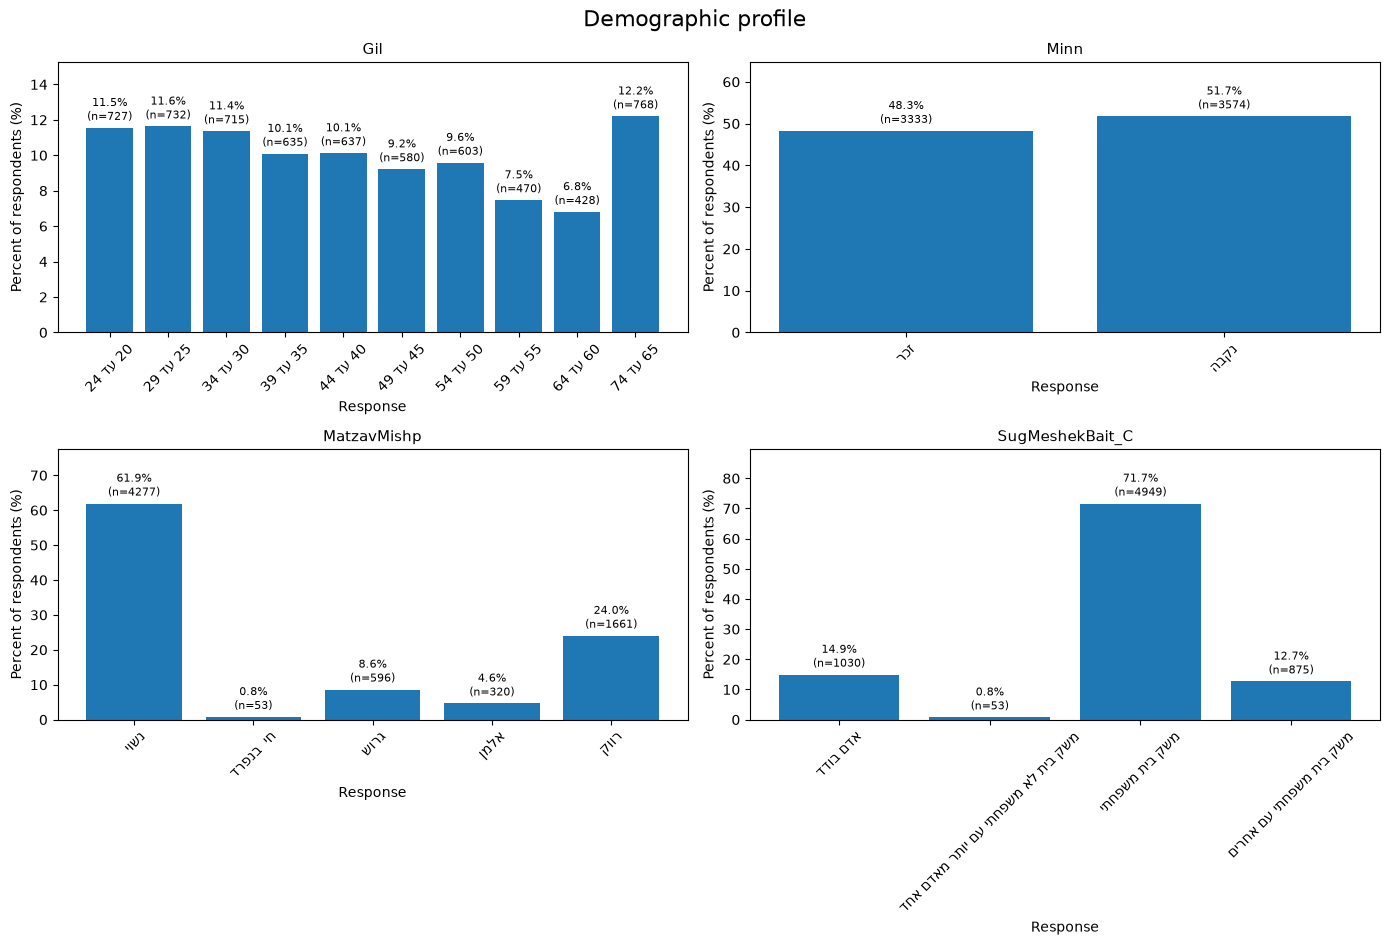

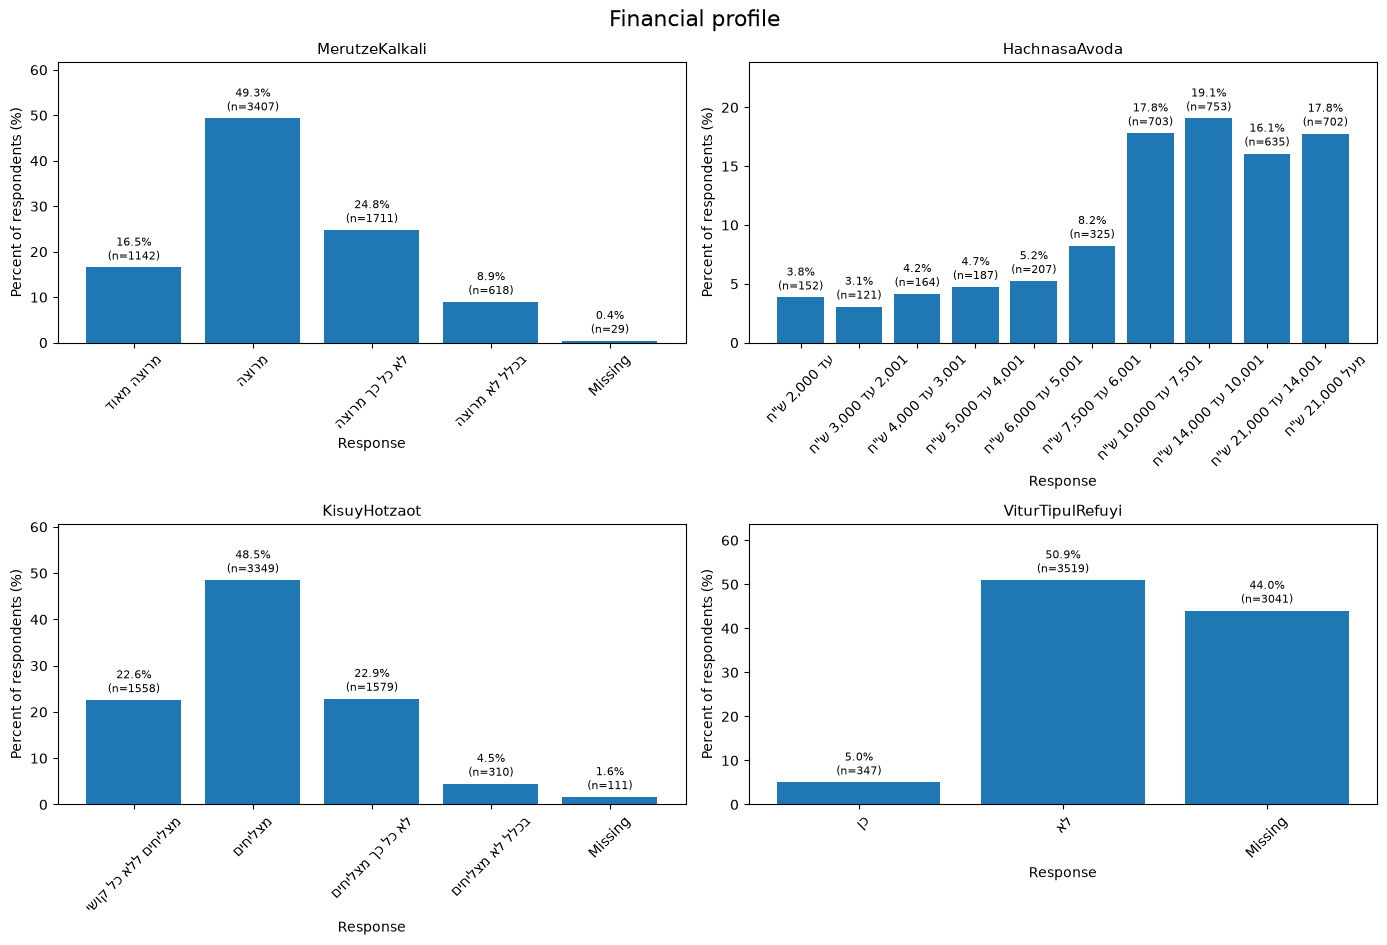

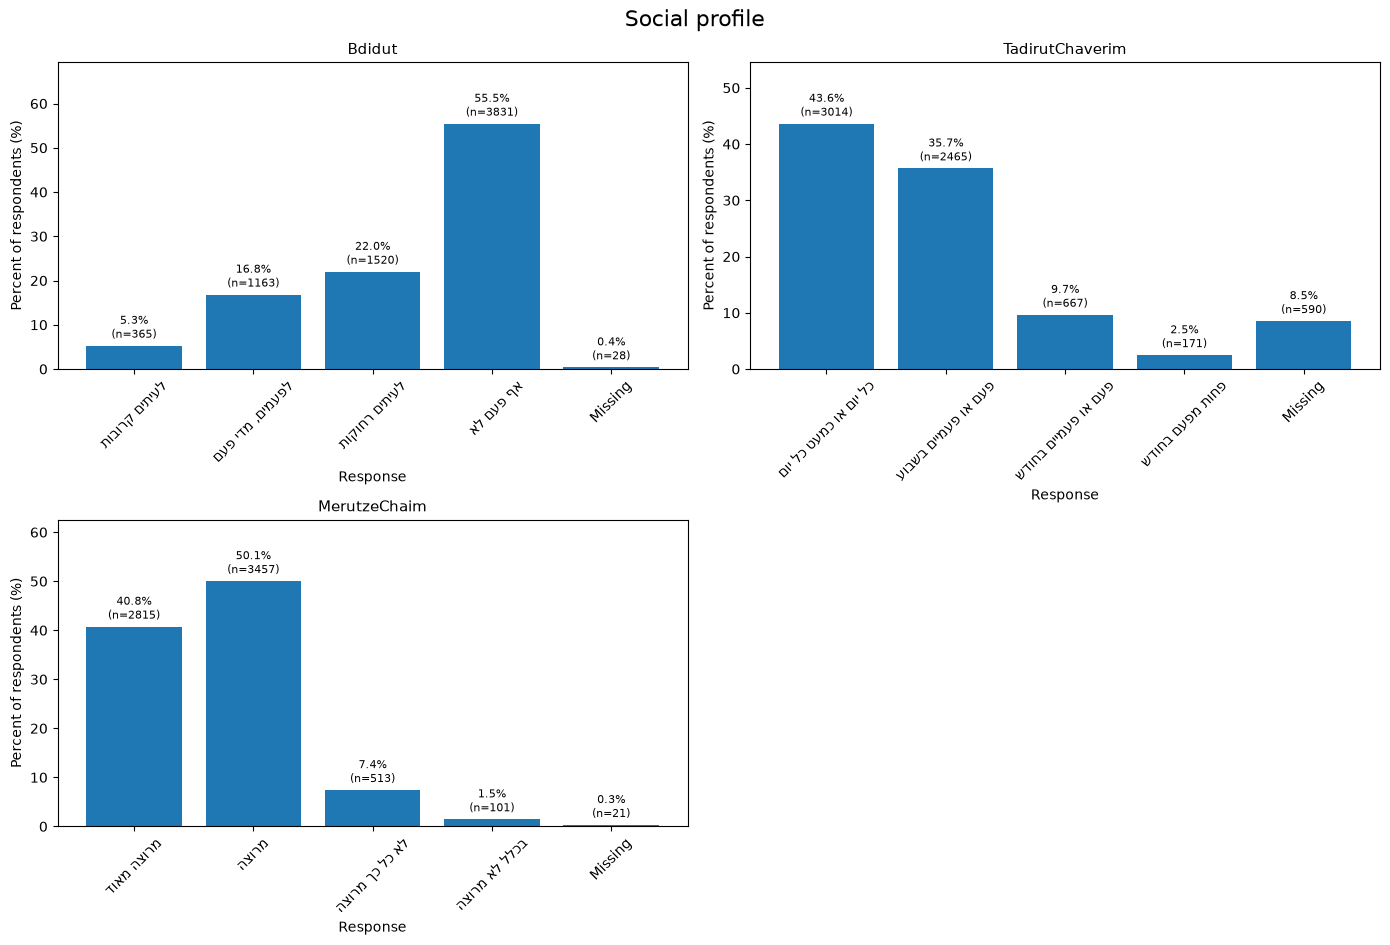

In [18]:
for group_name, variables in eda_groups.items():
    plot_frequency_group(
        data=df,
        variables=variables,
        title=group_name,
        codebook=codebook
    )


## 7. Target Construction and Feature Engineering


### 7.1 Target Variable: Financial Vulnerability
The primary outcome of this study is **financial vulnerability**. Rather than relying on a single survey question, the target variable was constructed from multiple indicators reflecting financial hardship. These indicators capture respondents' ability to meet routine expenses, cope with unexpected costs, and whether financial constraints led them to forgo essential needs such as medical care, medication, dental treatment, or adequate food.

Before constructing the composite target, the distribution of each indicator was examined to verify the coding of the response categories and the extent of missing values.

In [19]:
risk_columns = ["KisuyHotzaot", "ViturTipulRefuyi","ViturTerufot", "ViturTipulShinaim",
                "ViturOchel", "ViturAruchaChama","HotzaaLoTzfuya", "KisuyHotzaotBshana"]

for col in risk_columns:
    print(df[col].value_counts(dropna=False))


KisuyHotzaot
2.0    3349
3.0    1579
1.0    1558
4.0     310
NaN     111
Name: count, dtype: int64
ViturTipulRefuyi
2.0    3519
NaN    3041
1.0     347
Name: count, dtype: int64
ViturTerufot
2.0    4223
NaN    2420
1.0     264
Name: count, dtype: int64
ViturTipulShinaim
NaN    3118
2.0    2898
1.0     891
Name: count, dtype: int64
ViturOchel
2.0    6439
1.0     455
NaN      13
Name: count, dtype: int64
ViturAruchaChama
2.0    6579
1.0     316
NaN      12
Name: count, dtype: int64
HotzaaLoTzfuya
1.0    3756
2.0    2909
NaN     242
Name: count, dtype: int64
KisuyHotzaotBshana
2.0    4070
1.0    2763
NaN      74
Name: count, dtype: int64


In [20]:
# Coverage of expenses
risk_cover_expenses = np.where(
    df["KisuyHotzaot"].isna(),
    np.nan,
    np.where(df["KisuyHotzaot"].isin([3, 4]), 1, 0)
)

# Medical treatment
risk_medical = np.where(
    df["TipulRefuyi"] == 2,  # did not need treatment
    0,
    np.where(
        df["ViturTipulRefuyi"].isna(),
        np.nan,
        np.where(df["ViturTipulRefuyi"] == 1, 1, 0)
    )
)

# Prescription medicine
risk_medicine = np.where(
    df["Terufot"] == 2,  # did not need medicine
    0,
    np.where(
        df["ViturTerufot"].isna(),
        np.nan,
        np.where(df["ViturTerufot"] == 1, 1, 0)
    )
)

# Dental care
risk_dental = np.where(
    df["SHINAIM"] == 2,  # did not need dental treatment
    0,
    np.where(
        df["ViturTipulShinaim"].isna(),
        np.nan,
        np.where(df["ViturTipulShinaim"] == 1, 1, 0)
    )
)

# Food deprivation
risk_food = np.where(
    df["ViturOchel"].isna(),
    np.nan,
    np.where(df["ViturOchel"] == 1, 1, 0)
)

# Hot meal deprivation
risk_hot_meal = np.where(
    df["ViturAruchaChama"].isna(),
    np.nan,
    np.where(df["ViturAruchaChama"] == 1, 1, 0)
)

# Emergency expense
risk_emergency = np.where(
    df["HotzaaLoTzfuya"].isna(),
    np.nan,
    np.where(df["HotzaaLoTzfuya"] == 2, 1, 0)
)

# Income did not cover expenses during the year
risk_yearly_expenses = np.where(
    df["KisuyHotzaotBshana"].isna(),
    np.nan,
    np.where(df["KisuyHotzaotBshana"] == 1, 1, 0)
)

# ---------- Combine ----------

risk_df = pd.DataFrame({
    "risk_cover_expenses": risk_cover_expenses,
    "risk_medical": risk_medical,
    "risk_medicine": risk_medicine,
    "risk_dental": risk_dental,
    "risk_food": risk_food,
    "risk_hot_meal": risk_hot_meal,
    "risk_emergency": risk_emergency,
    "risk_yearly_expenses": risk_yearly_expenses
})

# How many indicators are missing?
risk_df["missing_risks"] = risk_df.isna().sum(axis=1)

# Composite score
risk_df["financial_risk_score"] = risk_df.iloc[:, :8].sum(
    axis=1,
    skipna=True
)

risk_df["missing_risks"].value_counts().sort_index()


missing_risks
0    6515
1     317
2      53
3       7
4       3
5       6
6       3
7       1
8       2
Name: count, dtype: int64

We constructed the financial risk score, which serves as the target variable (y), using eight questionnaire indicators reflecting different forms of financial hardship. Each indicator was coded as 1 when financial hardship was reported and 0 otherwise. Missing responses were retained as missing values, and the composite score was calculated by summing the available indicators, resulting in a theoretical range of 0 to 8. Since more than 94% of respondents had complete information and only a very small number had multiple missing indicators, we considered the score sufficiently reliable for further analysis. We next examine its distribution to determine an appropriate threshold for defining financial vulnerability.


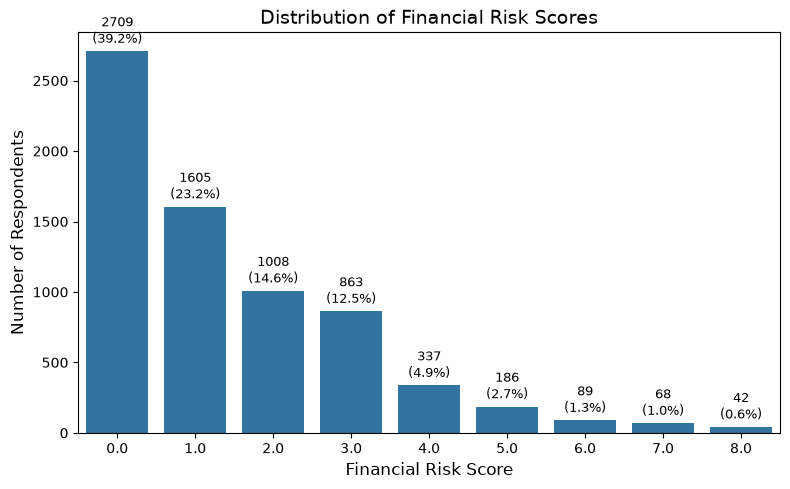

In [21]:

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=risk_df,
    x="financial_risk_score"
)

# Titles and axis labels
plt.title("Distribution of Financial Risk Scores", fontsize=14)
plt.xlabel("Financial Risk Score", fontsize=12)
plt.ylabel("Number of Respondents", fontsize=12)

# Add count and percentage labels
total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total

    ax.annotate(
        f"{count}\n({percentage:.1f}%)",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 3),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()


The distribution of the financial risk score is positively skewed, with most respondents reporting few or no indicators of financial hardship. To define the binary target variable, we classified respondents with a financial risk score of 3 or higher as financially vulnerable. This threshold was chosen because it reflects the presence of multiple, co-occurring indicators of financial difficulty rather than isolated financial challenges. A score of three or more suggests a broader pattern of financial vulnerability across different aspects of daily life, while also identifying a meaningful minority of respondents (approximately 23% of the sample), resulting in a balanced and interpretable target variable for subsequent predictive modeling.


In [22]:
# Require at least 5 observed indicators out of 8
valid_target = risk_df["missing_risks"] <= 3

risk_df["financial_vulnerable"] = np.where(
    valid_target,
    (risk_df["financial_risk_score"] >= 3).astype(int),
    np.nan
)

# Add back to original dataframe
df["financial_risk_score"] = risk_df["financial_risk_score"].copy()
df["financial_vulnerable"] = risk_df["financial_vulnerable"].copy()

# Diagnostics
counts = df["financial_vulnerable"].value_counts(dropna=False).sort_index()
percents = df["financial_vulnerable"].value_counts(dropna=False, normalize=True).sort_index() * 100

diagnostics = pd.DataFrame({
    "Count": counts,
    "Percent": percents.round(1)
})

print("Target distribution:")
display(diagnostics)


Target distribution:


C:\Users\ShaiSa\AppData\Local\Temp\ipykernel_11680\469255775.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["financial_risk_score"] = risk_df["financial_risk_score"].copy()
C:\Users\ShaiSa\AppData\Local\Temp\ipykernel_11680\469255775.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["financial_vulnerable"] = risk_df["financial_vulnerable"].copy()


,Count,Percent
financial_vulnerable,,
0.0,5309,76.9
1.0,1583,22.9
NaN,15,0.2


### 7.2 Predictor Variables


The helper below summarizes coded survey variables using labels from the official codebook. It is reused across all predictor domains to keep the audit consistent.


In [59]:
def print_value_counts_with_labels(data, columns, codebook):
    
    for col in columns:
        print(f"\n{'=' * 50}")
        print(col)

        if col not in data.columns:
            print("Column not found in dataframe")
            continue

        labels = (
            codebook.loc[
                codebook["variavle_name"] == col,
                ["code", "code_title"]
            ]
            .drop_duplicates(subset="code")
            .set_index("code")["code_title"]
            .to_dict()
        )

        counts = data[col].value_counts(dropna=False).sort_index()

        result = pd.DataFrame({
            "Count": counts.values,
            "Percent": (counts.values / len(data) * 100).round(1),
            "Label": [
                labels.get(value, str(value)) if pd.notna(value)
                else "Missing"
                for value in counts.index
            ]
        }, index=counts.index)

        result.index.name = col

        print(result)


#### 7.2.1 Demographic Variables


In [24]:
demographic_columns = [
    "YelidBrham","Minn", "Gil", "ShnatAliya", "MatzavMishp",
    "BenZugOved", "MechonitBashana", "NolduYeladim",
    "MispYeladim", "Dat", "SherutTzahal",
    "SherutLeumi", "RishyonNehiga"
]

print_value_counts_with_labels(
    data=df,
    columns=demographic_columns,
    codebook=codebook
)



YelidBrham
            Count  Percent Label
YelidBrham                      
1             947     13.7    כן
2            5960     86.3    לא

Minn
      Count  Percent Label
Minn                      
1      3333     48.3   זכר
2      3574     51.7  נקבה

Gil
     Count  Percent     Label
Gil                          
1      727     10.5  20 עד 24
2      732     10.6  25 עד 29
3      715     10.4  30 עד 34
4      635      9.2  35 עד 39
5      637      9.2  40 עד 44
6      580      8.4  45 עד 49
7      603      8.7  50 עד 54
8      470      6.8  55 עד 59
9      428      6.2  60 עד 64
10     768     11.1  65 עד 74
11     612      8.9       75+

ShnatAliya
            Count  Percent         Label
ShnatAliya                              
1.0            10      0.1       עד 1947
2.0           125      1.8  1948 עד 1954
3.0            75      1.1  1955 עד 1960
4.0           165      2.4  1961 עד 1971
5.0           105      1.5  1972 עד 1979
6.0            99      1.4  1980 עד 1989
7.0    

In [25]:
# Create a separate dataframe for modeling
model_df = df.copy()


# ============================================================
# Binary variables: recode 1 = Yes, 2 = No into 1/0
# ============================================================

binary_yes_no = [
    "YelidBrham",
    "NolduYeladim",
    "RishyonNehiga",
    "SherutTzahal",
    "SherutLeumi"
]

for col in binary_yes_no:
    model_df[col] = model_df[col].map({
        1: 1,
        2: 0
    })


# Gender: create one binary indicator
# 0 = Male, 1 = Female
model_df["female"] = model_df["Minn"].map({
    1: 0,
    2: 1
})


# ============================================================
# Ordinal / numeric variables
# ============================================================

# Age groups already have a meaningful order:
# 1 = 20–24 ... 11 = 75+
model_df["Gil"] = pd.to_numeric(
    model_df["Gil"],
    errors="coerce"
)

# Number of children:
# 7 represents 7 or more children
model_df["MispYeladim"] = pd.to_numeric(
    model_df["MispYeladim"],
    errors="coerce"
)

# Immigration year is relevant only to respondents
# who were not born in Israel.
# Code 0 represents "Born in Israel / Not applicable".
model_df["ShnatAliya"] = model_df["ShnatAliya"].fillna(0)

# ============================================================
# Nominal categorical variables
# ============================================================

nominal_columns = [
    "MatzavMishp",
    "Dat"
]

for col in nominal_columns:
    model_df[col] = model_df[col].astype("category")

# ============================================================
# Select demographic variables for the initial model
# ============================================================

demographic_model_columns = [
    "YelidBrham",
    "female",
    "Gil",
    "ShnatAliya",
    "MatzavMishp",
    "MispYeladim",
    "Dat",
    "SherutTzahal",
    "SherutLeumi",
    "RishyonNehiga"
]

X_demographic = model_df[demographic_model_columns].copy()


# Check the result
print("Shape:", X_demographic.shape)
print("\nData types:")
print(X_demographic.dtypes)

print("\nMissing values:")
print(
    X_demographic.isna()
    .sum()
    .sort_values(ascending=False)
)


Shape: (6907, 10)

Data types:
YelidBrham          int64
female              int64
Gil                 int64
ShnatAliya        float64
MatzavMishp      category
MispYeladim       float64
Dat              category
SherutTzahal      float64
SherutLeumi       float64
RishyonNehiga     float64
dtype: object

Missing values:
SherutLeumi      3493
SherutTzahal     1210
MispYeladim        14
Dat                12
RishyonNehiga       3
YelidBrham          0
female              0
MatzavMishp         0
Gil                 0
ShnatAliya          0
dtype: int64


#### 7.2.2 Household Variables


In [26]:
household_columns = ["SugMeshekBait_C", "Earners"]

print_value_counts_with_labels(
    data=df,
    columns=household_columns,
    codebook=codebook
)



SugMeshekBait_C
                 Count  Percent                               Label
SugMeshekBait_C                                                    
1                 1030     14.9                            אדם בודד
2                   53      0.8  משק בית לא משפחתי עם יותר מאדם אחד
3                 4949     71.7                      משק בית משפחתי
4                  875     12.7             משק בית משפחתי עם אחרים

Earners
         Count  Percent Label
Earners                      
0         1175     17.0     0
1         2206     31.9     1
2         2533     36.7     2
3          673      9.7     3
4          249      3.6     4
5           71      1.0    5+


In [27]:
# Household type
model_df["SugMeshekBait_C"] = (
    model_df["SugMeshekBait_C"]
    .astype("category")
)

# Number of earners
model_df["Earners"] = pd.to_numeric(
    model_df["Earners"],
    errors="coerce"
)

X_household = model_df[["SugMeshekBait_C", "Earners"]].copy()

# Check the result
print("Shape:", X_household.shape)
print("\nData types:")
print(X_household.dtypes)

print("\nMissing values:")
print(
    X_household.isna()
    .sum()
    .sort_values(ascending=False)
)


Shape: (6907, 2)

Data types:
SugMeshekBait_C    category
Earners               int64
dtype: object

Missing values:
SugMeshekBait_C    0
Earners            0
dtype: int64


#### 7.2.3 Health Variables


In [28]:
health_columns = ["BeayaBriut"]

print_value_counts_with_labels(
    data=df,
    columns=health_columns,
    codebook=codebook
)



BeayaBriut
            Count  Percent    Label
BeayaBriut                         
1.0          2210     32.0  כן     
2.0          4667     67.6       לא
NaN            30      0.4  Missing


In [29]:
model_df["health_problem"] = model_df["BeayaBriut"].map({
    1: 1,   # Yes
    2: 0    # No
})

X_health = model_df["health_problem"].copy()

# Check the result
print("Shape:", X_health.shape)
print("\nData types:")
print(X_health.dtypes)

print("Missing values:", X_health.isna().sum())


Shape: (6907,)

Data types:
float64
Missing values: 30


#### 7.2.4 Education Variables


In [30]:
education_columns = ["ShnotLimud", "IvritDibur", "IvritKria", "IvritKtiva", ]

print_value_counts_with_labels(
    data=df,
    columns=education_columns,
    codebook=codebook
)



ShnotLimud
            Count  Percent     Label
ShnotLimud                          
1.0           123      1.8    0 עד 4
2.0           274      4.0    5 עד 8
3.0           317      4.6   9 עד 10
4.0          2028     29.4  11 עד 12
5.0          1703     24.7  13 עד 15
6.0          2445     35.4  16 ומעלה
NaN            17      0.2   Missing

IvritDibur
            Count  Percent         Label
IvritDibur                              
1            5024     72.7     טובה מאוד
2             798     11.6          טובה
3             546      7.9       בינונית
4             368      5.3          חלשה
5             171      2.5  לא יודע בכלל

IvritKria
           Count  Percent         Label
IvritKria                              
1           4953     71.7     טובה מאוד
2            721     10.4          טובה
3            511      7.4       בינונית
4            413      6.0          חלשה
5            309      4.5  לא יודע בכלל

IvritKtiva
            Count  Percent         Label
IvritKtiva  

In [31]:
display(model_df[
    [
        "IvritDibur",
        "IvritKria",
        "IvritKtiva"
    ]
].corr(method="spearman"))

hebrew_items = df[
    ["IvritDibur", "IvritKria", "IvritKtiva"]
].dropna()

k = hebrew_items.shape[1]

item_variances = hebrew_items.var(axis=0, ddof=1)
total_variance = hebrew_items.sum(axis=1).var(ddof=1)

cronbach_alpha = (
    k / (k - 1)
) * (
    1 - item_variances.sum() / total_variance
)

print(f"Cronbach's alpha = {cronbach_alpha:.3f}")


,IvritDibur,IvritKria,IvritKtiva
IvritDibur,1.000000,0.904618,0.888983
IvritKria,0.904618,1.000000,0.965273
IvritKtiva,0.888983,0.965273,1.000000


Cronbach's alpha = 0.971


The three Hebrew proficiency items are strongly correlated and measure closely related skills. To reduce redundancy, they are reverse-coded so that higher values indicate better proficiency and combined into a single mean score.


In [32]:
reverse_map = {
    1: 5,
    2: 4,
    3: 3,
    4: 2,
    5: 1
}

hebrew_cols = [
    "IvritDibur",
    "IvritKria",
    "IvritKtiva"
]

for col in hebrew_cols:
    model_df[col] = model_df[col].replace(reverse_map)

model_df["hebrew_proficiency"] = model_df[hebrew_cols].mean(axis=1)

print(model_df["hebrew_proficiency"].value_counts(dropna=False))


hebrew_proficiency
5.000000    4764
4.000000     497
3.000000     322
2.000000     235
4.333333     173
1.000000     161
2.333333     132
4.666667     131
3.666667     130
3.333333     124
1.333333      90
2.666667      89
1.666667      59
Name: count, dtype: int64


In [33]:
X_education = model_df[["ShnotLimud", "hebrew_proficiency"]].copy()

# Check the result
print("Shape:", X_education.shape)
print("\nData types:")
print(X_education.dtypes)

print("\nMissing values:")
print(
    X_education.isna()
    .sum()
    .sort_values(ascending=False)
)


Shape: (6907, 2)

Data types:
ShnotLimud            float64
hebrew_proficiency    float64
dtype: object

Missing values:
ShnotLimud            17
hebrew_proficiency     0
dtype: int64


#### 7.2.5 Employment Variables


In [34]:
employment_columns = ["MatzavTaasukaM_C", "MispMekomot_C", "Menahel_wp", "MaamadAvoda_C_wp",
                     "AvodaYamim", "Oved35_wp", "HekefMisra_C_wp",
                     "MerutzeAvoda_wp", "HachnasaAvodaNeto"]

print_value_counts_with_labels(
    data=df,
    columns=employment_columns,
    codebook=codebook
)



MatzavTaasukaM_C
                  Count  Percent                Label
MatzavTaasukaM_C                                     
1                  4676     67.7                מועסק
2                   248      3.6           בלתי מועסק
3                  1983     28.7  לא שייך לכוח העבודה

MispMekomot_C
               Count  Percent                    Label
MispMekomot_C                                         
1.0             4193     60.7     עובד במקום עבודה אחד
2.0              320      4.6  עובד במספר מקומות עבודה
NaN             2394     34.7                  Missing

Menahel_wp
            Count  Percent    Label
Menahel_wp                         
1.0          1203     17.4      כן 
2.0          3283     47.5      לא 
NaN          2421     35.1  Missing

MaamadAvoda_C_wp
                  Count  Percent                        Label
MaamadAvoda_C_wp                                             
1.0                3891     56.3    שכיר (כולל חבר קואופרטיב)
2.0                 750   

Missing values in several employment variables are largely structural because the questions were asked only of employed respondents. A dedicated **Not employed** category is therefore assigned where appropriate, distinguishing structural non-response from unknown values.


In [35]:
# ============================================================
# Structural missing values in employment-related variables
# ============================================================

# Employment status:
# 1 = Employed
# 2 = Unemployed
# 3 = Not in the labor force

not_employed_mask = model_df["MatzavTaasukaM_C"].isin([2, 3])

# For each variable:
# key   = column name
# value = new code meaning "Not employed / Not applicable"
not_employed_codes = {
    "MispMekomot_C": 3,        # Existing codes: 1–2
    "Menahel_wp": 3,            # Existing codes: 1–2
    "MaamadAvoda_C_wp": 4,      # Existing codes: 1–3
    "AvodaYamim": 99,           # Existing codes: 1–7 and 98
    "Oved35_wp": 3,             # Existing codes: 1–2
    "HekefMisra_C_wp": 3,       # Existing codes: 1–2
    "MerutzeAvoda_wp": 5,       # Existing codes: 1–4
    "HachnasaAvodaNeto": 12     # Existing codes: 1–11
}

# Fill only structural missing values among non-employed respondents
for col, new_code in not_employed_codes.items():

    if col not in model_df.columns:
        print(f"Warning: {col} was not found in model_df")
        continue

    model_df.loc[
        not_employed_mask & model_df[col].isna(),
        col
    ] = new_code


# ============================================================
# Print distributions with labels from the codebook
# ============================================================

for col, new_code in not_employed_codes.items():

    if col not in model_df.columns:
        continue

    print(f"\n{'=' * 50}")
    print(col)

    # Labels from the original codebook
    labels = (
        codebook.loc[
            codebook["variavle_name"] == col,
            ["code", "code_title"]
        ]
        .drop_duplicates(subset="code")
        .set_index("code")["code_title"]
        .to_dict()
    )

    # Add the new category created during feature engineering
    labels[new_code] = "לא מועסק"

    counts = (
        model_df[col]
        .value_counts(dropna=False)
        .sort_index()
    )

    result = pd.DataFrame({
        "Count": counts,
        "Percent": (counts / len(model_df) * 100).round(1),
        "Label": [
            labels.get(value, str(value))
            if pd.notna(value)
            else "Missing"
            for value in counts.index
        ]
    })

    result.index.name = col

    print(result)



MispMekomot_C
               Count  Percent                    Label
MispMekomot_C                                         
1.0             4193     60.7     עובד במקום עבודה אחד
2.0              320      4.6  עובד במספר מקומות עבודה
3.0             2231     32.3                 לא מועסק
NaN              163      2.4                  Missing

Menahel_wp
            Count  Percent     Label
Menahel_wp                          
1.0          1203     17.4       כן 
2.0          3283     47.5       לא 
3.0          2231     32.3  לא מועסק
NaN           190      2.8   Missing

MaamadAvoda_C_wp
                  Count  Percent                        Label
MaamadAvoda_C_wp                                             
1.0                3891     56.3    שכיר (כולל חבר קואופרטיב)
2.0                 750     10.9   עצמאי או מנהל חברה בבעלותו
3.0                  20      0.3                         אחר 
4.0                2231     32.3                     לא מועסק
NaN                  15      0.

In [36]:
mapping = {
    11: 0,   # no work income
    12: 0,   # not employed
    1: 1,
    2: 2,
    3: 3,
    4: 4,
    5: 5,
    6: 6,
    7: 7,
    8: 8,
    9: 9,
    10: 10
}

model_df["work_income_level"] = (
    model_df["HachnasaAvodaNeto"]
    .replace(mapping)
)

employment_categorical = [
    "MispMekomot_C",
    "Menahel_wp",
    "MaamadAvoda_C_wp",
    "AvodaYamim",
    "HekefMisra_C_wp",
    "MerutzeAvoda_wp"
]

for col in employment_categorical:
    model_df[col] = model_df[col].astype("category")

X_employment = model_df[[
    "MispMekomot_C",
    "Menahel_wp",
    "MaamadAvoda_C_wp",
    "AvodaYamim",
    "HekefMisra_C_wp",
    "MerutzeAvoda_wp",
    "work_income_level"
]].copy()

# Check the result
print("Shape:", X_employment.shape)
print("\nData types:")
print(X_employment.dtypes)

print("\nMissing values:")
print(
    X_employment.isna()
    .sum()
    .sort_values(ascending=False)
)


Shape: (6907, 7)

Data types:
MispMekomot_C        category
Menahel_wp           category
MaamadAvoda_C_wp     category
AvodaYamim           category
HekefMisra_C_wp      category
MerutzeAvoda_wp      category
work_income_level     float64
dtype: object

Missing values:
work_income_level    575
Menahel_wp           190
AvodaYamim           178
HekefMisra_C_wp      177
MispMekomot_C        163
MerutzeAvoda_wp      104
MaamadAvoda_C_wp      15
dtype: int64


#### 7.2.6 Social Participation Variables


In [37]:
hevrati_columns = ["HitnadvutShana", "TrumaShana", "TrumaSchum"]

print_value_counts_with_labels(
    data=df,
    columns=hevrati_columns,
    codebook=codebook
)



HitnadvutShana
                Count  Percent    Label
HitnadvutShana                         
1.0              2086     30.2       כן
2.0              4809     69.6       לא
NaN                12      0.2  Missing

TrumaShana
            Count  Percent    Label
TrumaShana                         
1.0          3855     55.8       כן
2.0          3021     43.7       לא
NaN            31      0.4  Missing

TrumaSchum
            Count  Percent             Label
TrumaSchum                                  
1.0           542      7.8        עד 100 ש"ח
2.0          1298     18.8   בין 500-101 ש"ח
3.0           729     10.6  בין 1000-501 ש"ח
4.0          1117     16.2      מעל 1000 ש"ח
NaN          3221     46.6           Missing


In [38]:
X_hevrati = model_df[["HitnadvutShana", "TrumaShana"]].copy()

# Check the result
print("Shape:", X_hevrati.shape)
print("\nData types:")
print(X_hevrati.dtypes)

print("\nMissing values:")
print(
    X_hevrati.isna()
    .sum()
    .sort_values(ascending=False)
)


Shape: (6907, 2)

Data types:
HitnadvutShana    float64
TrumaShana        float64
dtype: object

Missing values:
TrumaShana        31
HitnadvutShana    12
dtype: int64


#### 7.2.7 Financial Management and Behavior Variables


In [39]:
financial_columns = ["AchrayutKesef", "MenahelTazrim", "MishtameshAppMaakav", "HoraotKeva",
                     "HashkaotBank", "HassachMezuman", "HassachGmach", "HashkaotShukHon",
                     "HashkaotMatbeotVirt", "HashkaotAher",
                     "HotziPachot", "AvadYoter", "MacharParit", "HishtameshHisachon", "EzraMishpHaverim", "PanaLeRevacha", "HalvaaMeAvoda",
                     "HalvaaBank", "HalvaaPrati", "HalvaaGmach", "Overdraft", "LoAmadBatashlumim",
                     "YedaHashkaa", "SikunHashkaot", "LoHosech", "HeshbonotBazman", "MatarotKaspiot", "ShokelKniot"]

print_value_counts_with_labels(
    data=df,
    columns=financial_columns,
    codebook=codebook
)



AchrayutKesef
               Count  Percent                    Label
AchrayutKesef                                         
1.0             1963     28.4                      אני
2.0             3747     54.2  אני בשיתוף עם מישהו אחר
3.0             1170     16.9                מישהו אחר
NaN               27      0.4                  Missing

MenahelTazrim
               Count  Percent    Label
MenahelTazrim                         
1.0             5156     74.6    כן   
2.0             1724     25.0      לא 
NaN               27      0.4  Missing

MishtameshAppMaakav
                     Count  Percent    Label
MishtameshAppMaakav                         
1.0                   3620     52.4    כן   
2.0                   3257     47.2      לא 
NaN                     30      0.4  Missing

HoraotKeva
            Count  Percent    Label
HoraotKeva                         
1.0          4821     69.8    כן   
2.0          2032     29.4      לא 
NaN            54      0.8  Missing

Hashka

Before including the financial behavior items separately, we calculate Cronbach’s alpha to assess whether they form a sufficiently coherent single scale. A low or moderate alpha would support retaining them as distinct predictors rather than summing them.


In [40]:
financial_scale_cols = [
    "YedaHashkaa",
    "SikunHashkaot",
    "LoHosech",
    "HeshbonotBazman",
    "MatarotKaspiot",
    "ShokelKniot"
]

# Keep only complete cases for these items
financial_scale_data = model_df[financial_scale_cols].dropna()

# Number of items
k = financial_scale_data.shape[1]

# Variance of each item
item_variances = financial_scale_data.var(axis=0, ddof=1)

# Variance of the total score
total_score = financial_scale_data.sum(axis=1)
total_variance = total_score.var(ddof=1)

# Cronbach's alpha
cronbach_alpha = (
    k / (k - 1)
) * (
    1 - item_variances.sum() / total_variance
)

print(f"Number of complete cases: {len(financial_scale_data)}")
print(f"Cronbach's alpha: {cronbach_alpha:.3f}")


Number of complete cases: 6371
Cronbach's alpha: 0.363


In [41]:
# ============================================================
# Financial management variables
# ============================================================

# Binary variables
binary_financial_columns = [
    "MenahelTazrim",
    "MishtameshAppMaakav",
    "HoraotKeva",
    "HashkaotBank",
    "HassachMezuman",
    "HassachGmach",
    "HashkaotShukHon",
    "HashkaotMatbeotVirt",
    "HashkaotAher"
]

for col in binary_financial_columns:

    model_df[col] = model_df[col].map({
        1: 1,
        2: 0
    })

# Responsibility for household finances
# Keep as a nominal categorical variable
model_df["AchrayutKesef"] = model_df["AchrayutKesef"].astype("category")


# Ordinal financial behavior variables
financial_ordinal_columns = [
    "YedaHashkaa",
    "SikunHashkaot",
    "LoHosech",
    "HeshbonotBazman",
    "MatarotKaspiot",
    "ShokelKniot"
]

for col in financial_ordinal_columns:

    model_df[col] = pd.to_numeric(
        model_df[col],
        errors="coerce"
    )


In [42]:
X_finance = model_df[[
    "AchrayutKesef",
    "MenahelTazrim",
    "MishtameshAppMaakav",
    "HoraotKeva",
    "HashkaotBank",
    "HassachMezuman",
    "HassachGmach",
    "HashkaotShukHon",
    "HashkaotMatbeotVirt",
    "HashkaotAher",
    "YedaHashkaa",
    "SikunHashkaot",
    "LoHosech",
    "HeshbonotBazman",
    "MatarotKaspiot",
    "ShokelKniot"
]]

# Check the result
print("Shape:", X_finance.shape)
print("\nData types:")
print(X_finance.dtypes)

print("\nMissing values:")
print(
    X_finance.isna()
    .sum()
    .sort_values(ascending=False)
)


Shape: (6907, 16)

Data types:
AchrayutKesef          category
MenahelTazrim           float64
MishtameshAppMaakav     float64
HoraotKeva              float64
HashkaotBank            float64
HassachMezuman          float64
HassachGmach            float64
HashkaotShukHon         float64
HashkaotMatbeotVirt     float64
HashkaotAher            float64
YedaHashkaa             float64
SikunHashkaot           float64
LoHosech                float64
HeshbonotBazman         float64
MatarotKaspiot          float64
ShokelKniot             float64
dtype: object

Missing values:
MatarotKaspiot         285
LoHosech               259
YedaHashkaa            182
SikunHashkaot          172
ShokelKniot            147
HeshbonotBazman        147
HashkaotBank            97
HashkaotShukHon         82
HassachMezuman          81
HassachGmach            70
HashkaotAher            68
HashkaotMatbeotVirt     67
HoraotKeva              54
MishtameshAppMaakav     30
MenahelTazrim           27
AchrayutKesef        

#### 7.2.8 Financial Literacy


In [43]:
financial_literacy_columns = ["HishuvInflation", "HishuvRibit100_C", "HishuvRibitShana_C", "HishuvRibit5Shanim",
                             "BituyTsua", "BituyInflation", "BituyShukHahon"]
print_value_counts_with_labels(
    data=df,
    columns=financial_literacy_columns,
    codebook=codebook
)



HishuvInflation
                 Count  Percent                      Label
HishuvInflation                                           
1.0                255      3.7             יותר מאשר היום
2.0                378      5.5          אותו דבר כמו היום
3.0               4152     60.1                 פחות מהיום
4.0                337      4.9  לא ניתן לדעת מהמידע הקיים
NaN               1785     25.8                    Missing

HishuvRibit100_C
                  Count  Percent                                      Label
HishuvRibit100_C                                                           
0.0                5990     86.7                                          0
1.0                  75      1.1  ערך שונה מ-0 או לא ניתן לדעת מהמידע הקיים
NaN                 842     12.2                                    Missing

HishuvRibitShana_C
                    Count  Percent                      Label
HishuvRibitShana_C                                           
1.0                   191   

Financial literacy is operationalized as the number of correct answers across seven objective knowledge questions. Each correct response receives one point, producing a score from 0 to 7.


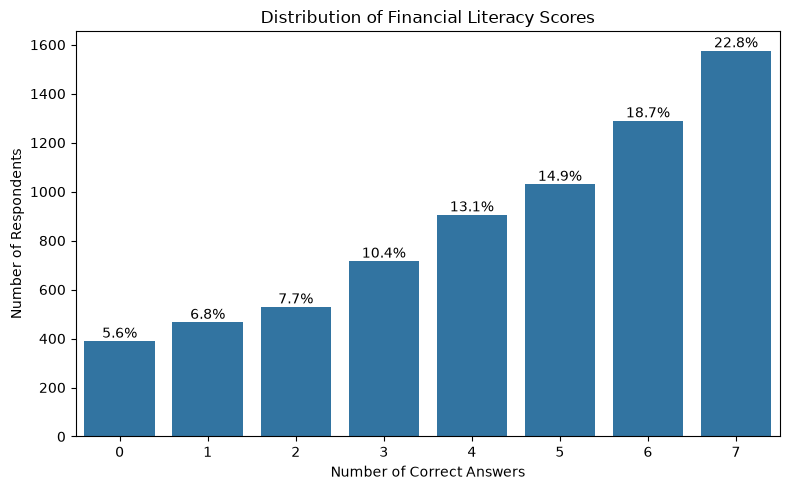

In [44]:
correct_answers = {
    "HishuvInflation": 3,
    "HishuvRibit100_C": 0,
    "HishuvRibitShana_C": 2,
    "HishuvRibit5Shanim": 1,
    "BituyTsua": 1,
    "BituyInflation": 1,
    "BituyShukHahon": 1
}

correct_columns = []

for col, correct_answer in correct_answers.items():

    new_col = f"{col}_Correct"

    # Correct = 1
    # Incorrect or missing = 0
    model_df[new_col] = (
        model_df[col] == correct_answer
    ).astype(int)

    correct_columns.append(new_col)


# Total number of correct answers (0–7)
model_df["FinancialLiteracyScore"] = model_df[
    correct_columns
].sum(axis=1)

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=model_df,
    x="FinancialLiteracyScore",
    order=range(8)
)

total = len(model_df)

for bar in ax.patches:
    count = bar.get_height()

    ax.annotate(
        f"{count / total * 100:.1f}%",
        (
            bar.get_x() + bar.get_width()/2,
            count
        ),
        ha="center",
        va="bottom"
    )

plt.title("Distribution of Financial Literacy Scores")
plt.xlabel("Number of Correct Answers")
plt.ylabel("Number of Respondents")

plt.tight_layout()
plt.show()


In [45]:
X_financial_literacy = model_df["FinancialLiteracyScore"].copy()

# Check the result
print("Shape:", X_financial_literacy.shape)
print("\nData types:")
print(X_financial_literacy.dtypes)

print("Missing values:", X_financial_literacy.isna().sum())


Shape: (6907,)

Data types:
int64
Missing values: 0


### 7.3 Final Modeling Dataset


In [46]:
# ============================================================
# Combine all feature groups into one modeling dataframe
# ============================================================


# Combine all feature tables by their row index
X = pd.concat(
    [
        X_demographic,
        X_household,
        X_health,
        X_education,
        X_employment,
        X_hevrati,
        X_finance,
        X_financial_literacy
    ],
    axis=1
)


# Remove duplicated columns, if the same feature appears more than once
duplicated_columns = X.columns[X.columns.duplicated()].tolist()

if duplicated_columns:
    print("Duplicated columns removed:")
    print(duplicated_columns)

    X = X.loc[:, ~X.columns.duplicated()]


# Add the target variable
model_data = X.copy()

model_data["financial_risk_score"] = (
    model_df["financial_risk_score"]
)


# Keep only rows for which the target is available
model_data = model_data.dropna(
    subset=["financial_risk_score"]
)


# Diagnostics
print("Combined dataframe shape:", model_data.shape)
print("Number of features:", X.shape[1])

print("\nMissing values by column:")
print(
    model_data.isna()
    .sum()
    .sort_values(ascending=False)
)

print(model_data.columns.to_list())


Combined dataframe shape: (6907, 42)
Number of features: 41

Missing values by column:
SherutLeumi               3493
SherutTzahal              1210
work_income_level          575
MatarotKaspiot             285
LoHosech                   259
Menahel_wp                 190
YedaHashkaa                182
AvodaYamim                 178
HekefMisra_C_wp            177
SikunHashkaot              172
MispMekomot_C              163
ShokelKniot                147
HeshbonotBazman            147
MerutzeAvoda_wp            104
HashkaotBank                97
HashkaotShukHon             82
HassachMezuman              81
HassachGmach                70
HashkaotAher                68
HashkaotMatbeotVirt         67
HoraotKeva                  54
TrumaShana                  31
health_problem              30
MishtameshAppMaakav         30
AchrayutKesef               27
MenahelTazrim               27
ShnotLimud                  17
MaamadAvoda_C_wp            15
MispYeladim                 14
HitnadvutShana

## 8. Multicollinearity Check


In [47]:

# Variables whose numbers are only category codes
nominal_cols = [
    "MatzavMishp", "Dat", "SherutTzahal", "SherutLeumi",
    "SugMeshekBait_C", "MispMekomot_C", "Menahel_wp",
    "MaamadAvoda_C_wp", "AvodaYamim", "HekefMisra_C_wp",
    "MerutzeAvoda_wp", "AchrayutKesef"
]

X_check = X.copy()

# Tell Phi-K that these variables are categorical
X_check[nominal_cols] = X_check[nominal_cols].astype("category")

# Association matrix for all variable types
corr = X_check.phik_matrix(
    interval_cols=[
        col for col in X_check.columns
        if col not in nominal_cols
    ]
)

# Keep each pair only once
high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
)

high_corr.columns = [
    "Variable 1",
    "Variable 2",
    "Association"
]

high_corr = (
    high_corr[high_corr["Association"] >= 0.85]
    .sort_values("Association", ascending=False)
    .reset_index(drop=True)
)

print(high_corr.to_string(index=False))


   Variable 1      Variable 2  Association
   AvodaYamim HekefMisra_C_wp     0.976991
   Menahel_wp HekefMisra_C_wp     0.948447
MispMekomot_C HekefMisra_C_wp     0.942950
MispMekomot_C      Menahel_wp     0.942944
   Menahel_wp      AvodaYamim     0.941262
MispMekomot_C      AvodaYamim     0.939711


To assess multicollinearity among the predictors, we calculated pairwise Phi-K associations, which are suitable for mixed data types (categorical, ordinal, binary, and numerical variables). A threshold of 0.85 was used to identify highly associated variables. Four employment-related variables (MispMekomot_C, Menahel_wp, AvodaYamim, and HekefMisra_C_wp) showed very high associations. This was expected because respondents who were not employed were assigned a dedicated "Not employed" category across these variables during feature engineering, creating substantial overlap. To reduce redundancy while preserving the most informative employment characteristic, we retained HekefMisra_C_wp (employment extent) and excluded MispMekomot_C, Menahel_wp, and AvodaYamim from the final model.


In [48]:
model_data = model_data.drop(
    columns=[
        "MispMekomot_C",
        "Menahel_wp",
        "AvodaYamim"
    ],
    errors="ignore"
)


In [49]:
print("Dataframe shape:", model_data.shape)

print("\nMissing values by column:")
print(
    model_data.isna()
    .sum()
    .sort_values(ascending=False)
)


Dataframe shape: (6907, 39)

Missing values by column:
SherutLeumi               3493
SherutTzahal              1210
work_income_level          575
MatarotKaspiot             285
LoHosech                   259
YedaHashkaa                182
HekefMisra_C_wp            177
SikunHashkaot              172
HeshbonotBazman            147
ShokelKniot                147
MerutzeAvoda_wp            104
HashkaotBank                97
HashkaotShukHon             82
HassachMezuman              81
HassachGmach                70
HashkaotAher                68
HashkaotMatbeotVirt         67
HoraotKeva                  54
TrumaShana                  31
MishtameshAppMaakav         30
health_problem              30
AchrayutKesef               27
MenahelTazrim               27
ShnotLimud                  17
MaamadAvoda_C_wp            15
MispYeladim                 14
HitnadvutShana              12
Dat                         12
RishyonNehiga                3
YelidBrham                   0
Gil            

## 9. Final Dataset Summary

The final table contains the engineered predictors and the financial vulnerability outcome after removing highly redundant employment variables. The following diagnostics provide a final check before preprocessing and model training.


In [50]:
print(f"Final dataset shape: {model_data.shape}")
print(f"Number of predictors: {model_data.shape[1] - 1}")
print("\nTarget distribution:")
print(model_data["financial_risk_score"].value_counts(normalize=True).sort_index().round(3))

# Optional export
# model_data.to_csv("social_survey_model_data.csv", index=False)


Final dataset shape: (6907, 39)
Number of predictors: 38

Target distribution:
financial_risk_score
0.0    0.392
1.0    0.232
2.0    0.146
3.0    0.125
4.0    0.049
5.0    0.027
6.0    0.013
7.0    0.010
8.0    0.006
Name: proportion, dtype: float64
